# PCEV ODQ Publication Figure: Age, Sex, Diagnosis

Publication-ready 3×4 figure showing PCEV results for age, sex, and diagnosis predictions using neural feature combinations with ODQ as confounder (no scanner).

**Figure Layout:**
- Row 1: Age prediction
- Row 2: Sex prediction  
- Row 3: Diagnosis prediction
- Column 1: Feature combination heatmap
- Column 2: h² violin plot (best combo vs all_features)
- Column 3: PCEV score distributions by phenotype groups
- Column 4: Effect size text box

## Imports and Configuration

In [4]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde

# Antes de crear la figura:
plt.rcParams['text.usetex'] = False          # Si usabas LaTeX, suele convertir todo a paths
plt.rcParams['svg.fonttype'] = 'none'        # Para SVG: no convertir fuentes a paths
plt.rcParams['pdf.fonttype'] = 42            # Para PDF: usa TrueType (editable en Illustrator)
plt.rcParams['ps.fonttype'] = 42

### TUNABLE PARAMETERS ###
KDE_BANDWIDTH = None  # None for automatic bandwidth selection, or float value
TEXTBOX_X = 0.95  # Text box X position (0-1)
TEXTBOX_Y = 0.95  # Text box Y position (0-1)
STAR_FONTSIZE = 30  # Font size for best combo star marker
STAR_COLOR = 'red'  # Color for best combo star
VIOLIN_COLORS = ["#555757", '#555757']  # [best_combo, all_features]
FONT_TITLE = 18  # Title font size
FONT_LABEL = 18  # Axis label font size
FONT_TICK = 16  # Tick label font size
FIGSIZE = (24, 12)  # Figure size (width, height)
WSPACE = 0.25  # Horizontal spacing between subplots
HSPACE = 0.4  # Vertical spacing between subplots

# Data paths
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'data' / 'derived').exists():
    for parent in REPO_ROOT.parents:
        if (parent / 'data' / 'derived').exists() and (parent / 'analysis').exists():
            REPO_ROOT = parent
            break
DATA_PATH = REPO_ROOT / 'data/derived/model_output_plus_exposome_data_v3.csv'
RESULTS_BASE = Path(os.environ.get('PCEV_RESULTS_DIR', '/data/workspaces/neuromodelling/rherzog/Brainlat/BOLD/pcev_results'))
AGE_DIR = RESULTS_BASE / 'age_odq_only_no_scanner'
SEX_DIR = RESULTS_BASE / 'sex_odq_only_no_scanner'
DIAG_DIR = RESULTS_BASE / 'diagnosis_odq_only_no_scanner'
FIG_DIR = REPO_ROOT / 'analysis/figures'
TABLE_DIR = REPO_ROOT / 'analysis/tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration loaded")

Configuration loaded


## Helper Functions

In [5]:
def parse_combo_label(label):
    """Parse combo label to extract feature groups."""
    if label == 'all_features':
        return None
    
    # Known single feature groups
    single_features = ['EI_ent', 'EI_rate', 'rate_I', 'rate_E', 'ent_E', 'ent_I']
    
    if label in single_features:
        return [label]
    
    # For pairs, identify the components
    for feat1 in single_features:
        for feat2 in single_features:
            if label == f"{feat1}_{feat2}" or label == f"{feat2}_{feat1}":
                return sorted([feat1, feat2])
    
    # Fallback: split by underscore and try to reconstruct
    parts = label.split('_')
    if len(parts) == 4:
        return sorted([f"{parts[0]}_{parts[1]}", f"{parts[2]}_{parts[3]}"])
    elif len(parts) == 3:
        if f"{parts[0]}_{parts[1]}" in single_features:
            return sorted([f"{parts[0]}_{parts[1]}", parts[2]])
        elif f"{parts[1]}_{parts[2]}" in single_features:
            return sorted([parts[0], f"{parts[1]}_{parts[2]}"])
    
    return [label]

def build_matrix(df, metric_col):
    """Build matrix of average metric values for feature combinations."""
    combos = [c for c in df['combo'].unique() if c != 'all_features']
    
    combo_groups = {}
    for c in combos:
        groups = parse_combo_label(c)
        if groups:
            combo_groups[c] = groups
    
    all_groups = set()
    for groups in combo_groups.values():
        all_groups.update(groups)
    groups_sorted = sorted(all_groups)
    
    matrix = pd.DataFrame(np.nan, index=groups_sorted, columns=groups_sorted)
    
    for combo, groups in combo_groups.items():
        avg_val = df[df['combo'] == combo][metric_col].mean()
        
        if len(groups) == 1:
            g = groups[0]
            matrix.loc[g, g] = avg_val
        elif len(groups) == 2:
            g1, g2 = groups
            matrix.loc[g1, g2] = avg_val
            matrix.loc[g2, g1] = avg_val
    
    return matrix

def find_best_combo(matrix):
    """Find combo with maximum value in matrix (includes diagonal)"""
    stacked = matrix.stack()
    max_idx = stacked.idxmax()
    if max_idx[0] == max_idx[1]:
        return max_idx[0]
    return f"{max_idx[0]}+{max_idx[1]}"

def combo_to_filename(combo_label):
    """Convert combo label to filename format (+ to _)"""
    return combo_label.replace('+', '_')

def create_heatmap(ax, matrix, title, max_idx=None, show_xticklabels=True):
    """Create a heatmap with consistent styling."""
    sns.heatmap(
        matrix,
        annot=False,
        cmap='gray_r',
        ax=ax,
        cbar=True,
        square=True,
        cbar_kws={'shrink': 0.8}
    )
    
    # Increase colorbar tick label fontsize and set only min/max ticks
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=FONT_TICK+4)
    # Set colorbar to show only min and max values with 2 decimal formatting
    vmin, vmax = cbar.vmin, cbar.vmax
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels([f'{vmin:.2f}', f'{vmax:.2f}'])
    
    ax.set_title(title, fontweight='bold', fontsize=FONT_TITLE)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    if show_xticklabels:
        # Make x-tick labels human-readable (remove underscores)
        xlabels = [label.get_text().replace('_', ' ') for label in ax.get_xticklabels()]
        ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=FONT_TICK+2)
    else:
        ax.set_xticklabels([])
    
    # Make y-tick labels human-readable (remove underscores)
    ylabels = [label.get_text().replace('_', ' ') for label in ax.get_yticklabels()]
    ax.set_yticklabels(ylabels, rotation=0, fontsize=FONT_TICK+2)
    
    # Remove tick marks but keep tick labels
    ax.tick_params(axis='both', which='both', length=0)
    
    # Add star at maximum
    if max_idx is not None:
        ax.text(
            max_idx[1] + 0.5,
            max_idx[0] + 0.5,
            '★',
            ha='center',
            va='center',
            fontsize=STAR_FONTSIZE,
            color=STAR_COLOR,
            fontweight='bold'
        )

print("Helper functions defined")


Helper functions defined


## Load Data

Load main dataset and PCEV results for age, sex, and diagnosis.

In [6]:
# Load main dataset with phenotype values
main_df = pd.read_csv(DATA_PATH, low_memory=False)
# Remove any subject whose country is New Zeland (case-insensitive, strip spaces)
main_df = main_df[~main_df['Country'].str.strip().str.lower().eq('new zeland')]
print(f"Main dataset: {main_df.shape}")


def merge_subject_covariate(scores_df, covariate_name):
    merged = scores_df.merge(
        main_df[['N_MEGA', covariate_name]],
        left_on='subject_id',
        right_on='N_MEGA',
        how='inner',
    ).drop(columns=['N_MEGA'])
    if covariate_name not in merged.columns:
        if f'{covariate_name}_x' in merged.columns:
            merged = merged.rename(columns={f'{covariate_name}_x': covariate_name})
        elif f'{covariate_name}_y' in merged.columns:
            merged = merged.rename(columns={f'{covariate_name}_y': covariate_name})
    return merged

# Load all h2_per_repeat files for Age
age_files = sorted(AGE_DIR.glob('*_h2_per_repeat.csv'))
age_data = []
for f in age_files:
    combo_name = f.stem.replace('_h2_per_repeat', '')
    df = pd.read_csv(f)
    df['combo'] = combo_name
    age_data.append(df)
age_df = pd.concat(age_data, ignore_index=True)

# Load all metrics_per_repeat files for Sex
sex_files = sorted(SEX_DIR.glob('*_metrics_per_repeat.csv'))
sex_data = []
for f in sex_files:
    combo_name = f.stem.replace('_metrics_per_repeat', '')
    df = pd.read_csv(f)
    df['combo'] = combo_name
    sex_data.append(df)
sex_df = pd.concat(sex_data, ignore_index=True)

# Load all metrics_per_repeat files for Diagnosis
diag_files = sorted(DIAG_DIR.glob('*_metrics_per_repeat.csv'))
diag_data = []
for f in diag_files:
    combo_name = f.stem.replace('_metrics_per_repeat', '')
    df = pd.read_csv(f)
    df['combo'] = combo_name
    diag_data.append(df)
diag_df = pd.concat(diag_data, ignore_index=True)

# Build matrices
age_matrix = build_matrix(age_df, 'h2_with')
sex_matrix = build_matrix(sex_df, 'cohens_d_with').abs()
diag_matrix = build_matrix(diag_df, 'epsilon_with')

# Find best combos
age_best_idx = np.unravel_index(np.nanargmax(age_matrix.values), age_matrix.shape)
sex_best_idx = np.unravel_index(np.nanargmax(sex_matrix.values), sex_matrix.shape)
diag_best_idx = np.unravel_index(np.nanargmax(diag_matrix.values), diag_matrix.shape)

age_best_combo = find_best_combo(age_matrix)
sex_best_combo = find_best_combo(sex_matrix)
diag_best_combo = find_best_combo(diag_matrix)

# Load specific files for violin plots and distributions
age_best_file = combo_to_filename(age_best_combo)
age_best_h2 = pd.read_csv(AGE_DIR / f'{age_best_file}_h2_per_repeat.csv')
age_all_h2 = pd.read_csv(AGE_DIR / 'all_features_h2_per_repeat.csv')
age_best_scores = pd.read_csv(AGE_DIR / f'{age_best_file}_subject_scores.csv')
age_best_scores = merge_subject_covariate(age_best_scores, 'Age')
# Average PCEV scores across repetitions per subject for age
age_best_scores_avg = age_best_scores.groupby(['subject_id', 'Age'], as_index=False)['score_with'].mean()

sex_best_file = combo_to_filename(sex_best_combo)
sex_best_metrics = pd.read_csv(SEX_DIR / f'{sex_best_file}_metrics_per_repeat.csv')
sex_all_metrics = pd.read_csv(SEX_DIR / 'all_features_metrics_per_repeat.csv')
sex_best_scores = pd.read_csv(SEX_DIR / f'{sex_best_file}_subject_scores.csv')
sex_best_scores = merge_subject_covariate(sex_best_scores, 'Sex')
# Average PCEV scores across repetitions per subject for sex
sex_best_scores_avg = sex_best_scores.groupby(['subject_id', 'Sex'], as_index=False)['score_with'].mean()

diag_best_file = combo_to_filename(diag_best_combo)
diag_best_metrics = pd.read_csv(DIAG_DIR / f'{diag_best_file}_metrics_per_repeat.csv')
diag_all_metrics = pd.read_csv(DIAG_DIR / 'all_features_metrics_per_repeat.csv')
diag_all_scores = pd.read_csv(DIAG_DIR / 'all_features_subject_scores.csv')
diag_all_scores = merge_subject_covariate(diag_all_scores, 'Diagnosis')
# Average PCEV scores across repetitions per subject for diagnosis
diag_all_scores_avg = diag_all_scores.groupby(['subject_id', 'Diagnosis'], as_index=False)['score_with'].mean()

print(f"Age: {age_best_combo}, Sex: {sex_best_combo}, Diagnosis: {diag_best_combo}")

Main dataset: (6988, 837)
Age: ent_E+ent_I, Sex: ent_I, Diagnosis: ent_E+ent_I


## Create 3×4 Publication Figure

Generate the complete figure with all panels.


Figure saved to: /home/rherzog/Documents/Brainlat/repo_test/analysis/figures


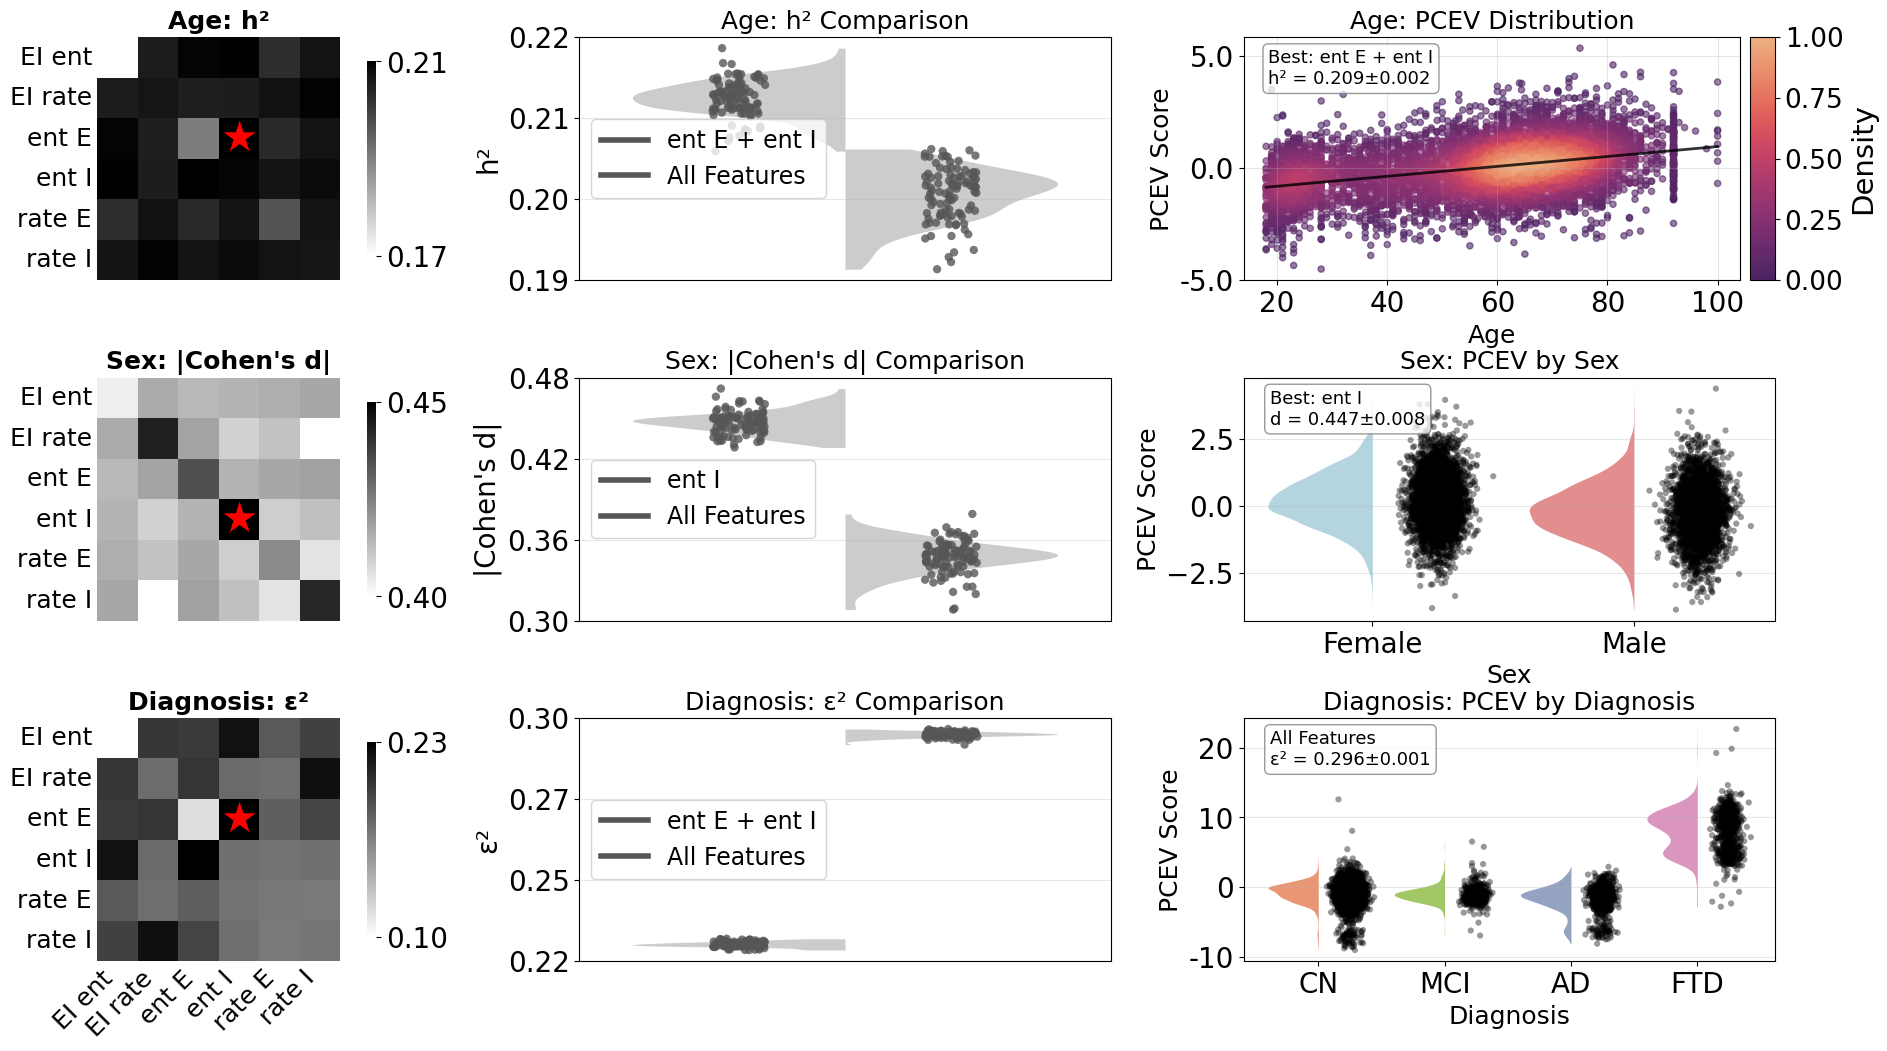

In [7]:
fig = plt.figure(figsize=FIGSIZE)
gs = gridspec.GridSpec(3, 3, figure=fig, wspace=WSPACE, hspace=HSPACE)  # Increase wspace for more spacing between columns

# ========== ROW 1: AGE ==========
ax_age_heat = fig.add_subplot(gs[0, 0])
create_heatmap(ax_age_heat, age_matrix, 'Age: h²', max_idx=age_best_idx, show_xticklabels=False)

# Age violin (h² comparison) - split violin with overlaid points
ax_age_viol = fig.add_subplot(gs[0, 1])
age_viol_data = pd.DataFrame({
    'h2': pd.concat([age_best_h2['h2_with'], age_all_h2['h2_with']]),
    'combo': [age_best_combo]*len(age_best_h2) + ['all_features']*len(age_all_h2),
    'x': [0]*len(age_best_h2) + [0]*len(age_all_h2)  # Same x position for split
})
# Create split violin
sns.violinplot(data=age_viol_data, x='x', y='h2', hue='combo', ax=ax_age_viol, 
               palette=VIOLIN_COLORS, inner='box', split=True, legend=False,
               linewidth=0, alpha=0.3, cut=0)
# Add stripplot in the middle
sns.stripplot(data=age_viol_data, x='x', y='h2', hue='combo', ax=ax_age_viol,
              palette=VIOLIN_COLORS, size=6, alpha=0.8, dodge=True, legend=False,
              linewidth=0, edgecolor='none')
# Create human-readable labels
age_best_label = age_best_combo.replace('_', ' ').replace('+', ' + ')
handles = [plt.Line2D([0], [0], color=VIOLIN_COLORS[0], lw=4, label=age_best_label),
           plt.Line2D([0], [0], color=VIOLIN_COLORS[1], lw=4, label='All Features')]
ax_age_viol.legend(handles=handles, loc='center left', fontsize=FONT_TICK+1)
ax_age_viol.set_title('Age: h² Comparison', fontsize=FONT_TITLE)
ax_age_viol.set_xlabel('')
ax_age_viol.set_ylabel('h²', fontsize=FONT_LABEL+2)
ax_age_viol.set_xticks([])
# Set 4 y-ticks: min, max, and 2 in between
ymin, ymax = ax_age_viol.get_ylim()
yticks = np.linspace(ymin, ymax, 4)
ax_age_viol.set_yticks(yticks)
ax_age_viol.set_yticklabels([f'{y:.2f}' for y in yticks])
ax_age_viol.tick_params(labelsize=FONT_TICK+4)
ax_age_viol.yaxis.grid(True, alpha=0.3)

# Age PCEV distribution (scatter with KDE) + text box inside
ax_age_dist = fig.add_subplot(gs[0, 2])
xy = age_best_scores_avg[['Age', 'score_with']].dropna().values.T
if KDE_BANDWIDTH:
    kde = gaussian_kde(xy, bw_method=KDE_BANDWIDTH)
else:
    kde = gaussian_kde(xy)
density = kde(xy)
# Normalize density to 0-1 range
density_normalized = (density - density.min()) / (density.max() - density.min())
scatter = ax_age_dist.scatter(xy[0], xy[1], c=density_normalized, s=20, cmap='flare_r', alpha=0.6)
# Add colorbar without deforming the plot (solid color, no transparency)
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax_age_dist)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(scatter, cax=cax, alpha=1.0)
cbar.solids.set_alpha(1.0)  # Make colorbar solid
cbar.set_label('Density', fontsize=FONT_LABEL+3)
cbar.ax.tick_params(labelsize=FONT_TICK+3)
# Add best-fit line in red
z = np.polyfit(xy[0], xy[1], 1)
p = np.poly1d(z)
x_line = np.linspace(xy[0].min(), xy[0].max(), 100)
ax_age_dist.plot(x_line, p(x_line), 'k-', linewidth=2, alpha=0.8)
ax_age_dist.set_xlabel('Age', fontsize=FONT_LABEL)
ax_age_dist.set_ylabel('PCEV Score', fontsize=FONT_LABEL)
ax_age_dist.set_title('Age: PCEV Distribution', fontsize=FONT_TITLE)
# Set 3 y-ticks: -5, 0, 5 and add grid
ax_age_dist.set_yticks([-5, 0, 5])
ax_age_dist.set_yticklabels(['-5.0', '0.0', '5.0'])
ax_age_dist.tick_params(labelsize=FONT_TICK+4)
ax_age_dist.yaxis.grid(True, alpha=0.3)
ax_age_dist.xaxis.grid(True, alpha=0.3)
# Add text box inside plot (upper left, fontsize+2, human-readable combo)
age_h2_mean = age_best_h2['h2_with'].mean()
age_h2_std = age_best_h2['h2_with'].std()
age_best_combo_hr = age_best_combo.replace('_', ' ').replace('+', ' + ')
age_text = f"Best: {age_best_combo_hr}\nh² = {age_h2_mean:.3f}±{age_h2_std:.3f}"
ax_age_dist.text(0.05, 0.95, age_text, transform=ax_age_dist.transAxes,
                 fontsize=13, verticalalignment='top', horizontalalignment='left',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# ========== ROW 2: SEX ==========
ax_sex_heat = fig.add_subplot(gs[1, 0])
create_heatmap(ax_sex_heat, sex_matrix, 'Sex: |Cohen\'s d|', max_idx=sex_best_idx, show_xticklabels=False)

# Sex violin (Cohen's d comparison)
ax_sex_viol = fig.add_subplot(gs[1, 1])
sex_viol_data = pd.DataFrame({
    'cohens_d': pd.concat([sex_best_metrics['cohens_d_with'].abs(), sex_all_metrics['cohens_d_with'].abs()]),
    'combo': [sex_best_combo]*len(sex_best_metrics) + ['all_features']*len(sex_all_metrics),
    'x': [0]*len(sex_best_metrics) + [0]*len(sex_all_metrics)  # Same x position for split
})
# Create split violin
sns.violinplot(data=sex_viol_data, x='x', y='cohens_d', hue='combo', ax=ax_sex_viol,
               palette=VIOLIN_COLORS, inner='box', split=True, legend=False,
               linewidth=0, alpha=0.3, cut=0)
# Add stripplot in the middle
sns.stripplot(data=sex_viol_data, x='x', y='cohens_d', hue='combo', ax=ax_sex_viol,
              palette=VIOLIN_COLORS, size=6, alpha=0.8, dodge=True, legend=False,
              linewidth=0, edgecolor='none')
# Create human-readable labels
sex_best_label = sex_best_combo.replace('_', ' ')
handles = [plt.Line2D([0], [0], color=VIOLIN_COLORS[0], lw=4, label=sex_best_label),
           plt.Line2D([0], [0], color=VIOLIN_COLORS[1], lw=4, label='All Features')]
ax_sex_viol.legend(handles=handles, loc='center left', fontsize=FONT_TICK+1)
ax_sex_viol.set_title('Sex: |Cohen\'s d| Comparison', fontsize=FONT_TITLE)
ax_sex_viol.set_xlabel('')
ax_sex_viol.set_ylabel('|Cohen\'s d|', fontsize=FONT_LABEL+2)
ax_sex_viol.set_xticks([])
# Set 4 y-ticks: min, max, and 2 in between
ymin, ymax = ax_sex_viol.get_ylim()
yticks = np.linspace(ymin, ymax, 4)
ax_sex_viol.set_yticks(yticks)
ax_sex_viol.set_yticklabels([f'{y:.2f}' for y in yticks])
ax_sex_viol.tick_params(labelsize=FONT_TICK+4)
ax_sex_viol.yaxis.grid(True, alpha=0.3)

# Sex PCEV distribution (by sex) + text box inside
ax_sex_dist = fig.add_subplot(gs[1, 2])
# Use average PCEV scores per subject for sex
sns.violinplot(data=sex_best_scores_avg, x='Sex', y='score_with', hue='Sex', ax=ax_sex_dist,
               palette=['lightblue', 'lightcoral'], inner='box', legend=False,
               split=False, cut=0, linewidth=0)
# Modify violins to show only left half
for collection in ax_sex_dist.collections:
    if hasattr(collection, 'get_paths'):
        for path in collection.get_paths():
            vertices = path.vertices
            # Keep only left half of violin (x < center)
            center_x = vertices[:, 0].mean()
            mask = vertices[:, 0] <= center_x
            # Shift vertices to align properly
            vertices[~mask, 0] = center_x
# Add stripplot on the right side (where the right half of violin would be)
for i, sex in enumerate(['Female', 'Male']):
    sex_data = sex_best_scores_avg[sex_best_scores_avg['Sex'] == sex]['score_with']
    # Add jitter to x position (shift to right side, increase offset for more spacing)
    x_pos = np.random.normal(i + 0.25, 0.05, size=len(sex_data))
    ax_sex_dist.scatter(x_pos, sex_data, c='black', s=20, alpha=0.4, 
                       edgecolors='none', linewidths=0, zorder=3)
ax_sex_dist.set_title('Sex: PCEV by Sex', fontsize=FONT_TITLE)
ax_sex_dist.set_xlabel('Sex', fontsize=FONT_LABEL)
ax_sex_dist.set_ylabel('PCEV Score', fontsize=FONT_LABEL)
ax_sex_dist.tick_params(labelsize=FONT_TICK+4)
ax_sex_dist.yaxis.grid(True, alpha=0.3)
# Add text box inside plot (upper left, fontsize+2, human-readable combo)
sex_d_mean = sex_best_metrics['cohens_d_with'].mean()
sex_d_std = sex_best_metrics['cohens_d_with'].std()
sex_best_combo_hr = sex_best_combo.replace('_', ' ').replace('+', ' + ')
sex_text = f"Best: {sex_best_combo_hr}\nd = {sex_d_mean:.3f}±{sex_d_std:.3f}"
ax_sex_dist.text(0.05, 0.95, sex_text, transform=ax_sex_dist.transAxes,
                 fontsize=13, verticalalignment='top', horizontalalignment='left',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# ========== ROW 3: DIAGNOSIS ==========
ax_diag_heat = fig.add_subplot(gs[2, 0])
create_heatmap(ax_diag_heat, diag_matrix, 'Diagnosis: ε²', max_idx=diag_best_idx, show_xticklabels=True)

# Diagnosis violin (ε² comparison) - split violin with overlaid points
ax_diag_viol = fig.add_subplot(gs[2, 1])
diag_viol_data = pd.DataFrame({
    'epsilon': pd.concat([diag_best_metrics['epsilon_with'], diag_all_metrics['epsilon_with']]),
    'combo': [diag_best_combo]*len(diag_best_metrics) + ['all_features']*len(diag_all_metrics),
    'x': [0]*len(diag_best_metrics) + [0]*len(diag_all_metrics)  # Same x position for split
})
# Create split violin
sns.violinplot(data=diag_viol_data, x='x', y='epsilon', hue='combo', ax=ax_diag_viol,
               palette=VIOLIN_COLORS, inner='box', split=True, legend=False,
               linewidth=0, alpha=0.3, cut=0)
# Add stripplot in the middle
sns.stripplot(data=diag_viol_data, x='x', y='epsilon', hue='combo', ax=ax_diag_viol,
              palette=VIOLIN_COLORS, size=6, alpha=0.8, dodge=True, legend=False,
              linewidth=0, edgecolor='none')
# Create human-readable labels
diag_best_label = diag_best_combo.replace('_', ' ').replace('+', ' + ')
handles = [plt.Line2D([0], [0], color=VIOLIN_COLORS[0], lw=4, label=diag_best_label),
           plt.Line2D([0], [0], color=VIOLIN_COLORS[1], lw=4, label='All Features')]
ax_diag_viol.legend(handles=handles, loc='center left', fontsize=FONT_TICK+1)
ax_diag_viol.set_title('Diagnosis: ε² Comparison', fontsize=FONT_TITLE)
ax_diag_viol.set_xlabel('')
ax_diag_viol.set_ylabel('ε²', fontsize=FONT_LABEL+2)
ax_diag_viol.set_xticks([])
# Set 4 y-ticks: min, max, and 2 in between
ymin, ymax = ax_diag_viol.get_ylim()
yticks = np.linspace(ymin, ymax, 4)
ax_diag_viol.set_yticks(yticks)
ax_diag_viol.set_yticklabels([f'{y:.2f}' for y in yticks])
ax_diag_viol.tick_params(labelsize=FONT_TICK+4)
ax_diag_viol.yaxis.grid(True, alpha=0.3)

# Diagnosis PCEV distribution (by diagnosis) + text box inside
ax_diag_dist = fig.add_subplot(gs[2, 2])
diag_order = ['CN', 'MCI', 'AD', 'FTD']
# Use all_features model for diagnosis (not best combo)
diag_all_scores_ordered = diag_all_scores_avg[diag_all_scores_avg['Diagnosis'].isin(diag_order)]
# Skip first color of Set2 palette
import matplotlib.colors as mcolors
set2_colors = plt.cm.Set2.colors[1:5]  # Skip first color, use next 4
# Create half violins (left side only) with no edge
sns.violinplot(data=diag_all_scores_ordered, x='Diagnosis', y='score_with', hue='Diagnosis',
               order=diag_order, ax=ax_diag_dist, palette=set2_colors, inner='box', 
               legend=False, cut=0, linewidth=0)
# Modify violins to show only left half
for collection in ax_diag_dist.collections:
    if hasattr(collection, 'get_paths'):
        for path in collection.get_paths():
            vertices = path.vertices
            # Keep only left half of violin (x < center)
            center_x = vertices[:, 0].mean()
            mask = vertices[:, 0] <= center_x
            # Shift vertices to align properly
            vertices[~mask, 0] = center_x
# Add stripplot on the right side (where the right half of violin would be, increase offset for more spacing)
for i, diag in enumerate(diag_order):
    diag_data = diag_all_scores_ordered[diag_all_scores_ordered['Diagnosis'] == diag]['score_with']
    # Add jitter to x position (shift to right side, increase offset for more spacing)
    x_pos = np.random.normal(i + 0.25, 0.05, size=len(diag_data))
    ax_diag_dist.scatter(x_pos, diag_data, c='black', s=20, alpha=0.4, 
                        edgecolors='none', linewidths=0, zorder=3)
ax_diag_dist.set_title('Diagnosis: PCEV by Diagnosis', fontsize=FONT_TITLE)
ax_diag_dist.set_xlabel('Diagnosis', fontsize=FONT_LABEL)
ax_diag_dist.set_ylabel('PCEV Score', fontsize=FONT_LABEL)
# Set y-ticks: -10, 0, 10, 20 (no decimals, 0 included)
ax_diag_dist.set_yticks([-10, 0, 10, 20])
ax_diag_dist.set_yticklabels(['-10', '0', '10', '20'])
ax_diag_dist.tick_params(labelsize=FONT_TICK+4)
ax_diag_dist.yaxis.grid(True, alpha=0.3)
# Add text box inside plot (upper left, fontsize+2, all_features info)
diag_eps_mean = diag_all_metrics['epsilon_with'].mean()
diag_eps_std = diag_all_metrics['epsilon_with'].std()
diag_text = f"All Features\nε² = {diag_eps_mean:.3f}±{diag_eps_std:.3f}"
ax_diag_dist.text(0.05, 0.95, diag_text, transform=ax_diag_dist.transAxes,
                  fontsize=13, verticalalignment='top', horizontalalignment='left',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# Save figure (commented for fast iteration)
# fig.savefig(FIG_DIR / 'pcev_odq_phenotype_figure.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'pcev_odq_phenotype_figure.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'pcev_odq_phenotype_figure.svg', dpi=300, bbox_inches='tight')
print(f"\nFigure saved to: {FIG_DIR}")

plt.show()

In [8]:
# Number of unique subjects used for each phenotype (after merging with main_df)

# Age: subjects in age_best_scores_avg
n_age = age_best_scores_avg['subject_id'].nunique()

# Sex: subjects in sex_best_scores_avg
n_sex = sex_best_scores_avg['subject_id'].nunique()

# Diagnosis: subjects in diag_all_scores_avg
n_diag = diag_all_scores_avg['subject_id'].nunique()

# Number of unique countries in main_df
n_countries = main_df['Country'].nunique()
print(f"  Countries: {n_countries}")

print(f"Number of subjects used:")
print(f"  Age: {n_age}")
print(f"  Sex: {n_sex}")
print(f"  Diagnosis: {n_diag}")

  Countries: 16
Number of subjects used:
  Age: 6935
  Sex: 6935
  Diagnosis: 6935


In [9]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# Set seed for reproducibility
np.random.seed(42)

def paired_sign_flip_test(data_all, data_best, n_perm=10000, statistic="mean"):
    """
    Computes paired differences Δ = data_all − data_best,
    performs a two-sided sign-flip permutation test.
    Returns observed statistic and p-value.
    """
    diff = np.array(data_all) - np.array(data_best)
    n = len(diff)
    
    if statistic == "mean":
        obs_stat = np.mean(diff)
    elif statistic == "median":
        obs_stat = np.median(diff)
    else:
        raise ValueError("statistic must be 'mean' or 'median'")
        
    # Generate random signs matrix (n_perm, n)
    signs = np.random.choice([-1, 1], size=(n_perm, n))
    
    # Compute permuted statistics
    if statistic == "mean":
        # Mean of (signs * diff) along axis 1
        perm_stats = np.mean(signs * diff, axis=1)
    elif statistic == "median":
        perm_stats = np.median(signs * diff, axis=1)
        
    # Two-sided p-value
    p_val = np.mean(np.abs(perm_stats) >= np.abs(obs_stat))
    
    return obs_stat, p_val

def bootstrap_ci(data, n_boot=10000, statistic="mean"):
    """
    Returns a 95% bootstrap CI over repeats.
    """
    data = np.array(data)
    n = len(data)
    
    # Bootstrap resampling indices
    indices = np.random.randint(0, n, size=(n_boot, n))
    samples = data[indices]
    
    if statistic == "mean":
        boot_stats = np.mean(samples, axis=1)
    elif statistic == "median":
        boot_stats = np.median(samples, axis=1)
    else:
        raise ValueError("statistic must be 'mean' or 'median'")
        
    # 95% CI
    ci_lower = np.percentile(boot_stats, 2.5)
    ci_upper = np.percentile(boot_stats, 97.5)
    
    return ci_lower, ci_upper

def get_simple_stats(data):
    """Mean and SD for display."""
    return np.mean(data), np.std(data, ddof=1), len(data)

# Collect data for analysis
# Note: Using absolute values for Cohen's d as we care about magnitude of effect
analysis_targets = [
    {
        "Phenotype": "Age",
        "Metric": "h²",
        "Best_Data": age_best_h2['h2_with'].values,
        "All_Data": age_all_h2['h2_with'].values,
        "Best_Label": age_best_combo
    },
    {
        "Phenotype": "Sex",
        "Metric": "|Cohen's d|",
        "Best_Data": sex_best_metrics['cohens_d_with'].abs().values,
        "All_Data": sex_all_metrics['cohens_d_with'].abs().values,
        "Best_Label": sex_best_combo
    },
    {
        "Phenotype": "Sex",
        "Metric": "h²",
        "Best_Data": sex_best_metrics['h2_with'].values,
        "All_Data": sex_all_metrics['h2_with'].values,
        "Best_Label": sex_best_combo
    },
    {
        "Phenotype": "Diagnosis",
        "Metric": "ε²",
        "Best_Data": diag_best_metrics['epsilon_with'].values,
        "All_Data": diag_all_metrics['epsilon_with'].values,
        "Best_Label": diag_best_combo
    },
    {
        "Phenotype": "Diagnosis",
        "Metric": "h²",
        "Best_Data": diag_best_metrics['h2_with'].values,
        "All_Data": diag_all_metrics['h2_with'].values,
        "Best_Label": diag_best_combo
    }
]

results_list = []

for target in analysis_targets:
    # Descriptive stats
    best_mean, best_std, n = get_simple_stats(target["Best_Data"])
    all_mean, all_std, _ = get_simple_stats(target["All_Data"])
    
    # 1. Paired sign-flip permutation test
    obs_stat, pval = paired_sign_flip_test(target["All_Data"], target["Best_Data"], n_perm=10000, statistic="mean")
    
    # 2. Bootstrap CI for the difference
    diffs = np.array(target["All_Data"]) - np.array(target["Best_Data"])
    ci_lower, ci_upper = bootstrap_ci(diffs, n_boot=10000, statistic="mean")
    
    # Format for table
    pval_fmt = "< 0.001" if pval < 0.001 else f"{pval:.4f}"
    
    results_list.append({
        "Phenotype": target["Phenotype"],
        "Metric": target["Metric"],
        "Best Subset": target["Best_Label"],
        "Best Mean (SD)": f"{best_mean:.6f} ({best_std:.6f})",
        "All Features Mean (SD)": f"{all_mean:.6f} ({all_std:.6f})",
        "N": n,
        "Test": "Paired sign-flip permutation (repeat-level)",
        "Δ (All - Best)": f"{obs_stat:.6f}",
        "Δ 95% CI": f"[{ci_lower:.6f}, {ci_upper:.6f}",
        "P-value": pval
    })

# Create and display table
stats_df = pd.DataFrame(results_list)
display(Markdown("### Statistical Comparison: Best Subset vs. All Features (Non-parametric)"))
display(stats_df)

# Print Markdown for easy copying
print(stats_df.to_markdown(index=False))

stats_df.to_csv(TABLE_DIR / 'pcev_phenotypes_best_vs_all.csv', index=False)

### Statistical Comparison: Best Subset vs. All Features (Non-parametric)

,Phenotype,Metric,Best Subset,Best Mean (SD),All Features Mean (SD),N,Test,Δ (All - Best),Δ 95% CI,P-value
0,Age,h²,ent_E+ent_I,0.209139 (0.002279),0.196883 (0.003390),100,Paired sign-flip permutation (repeat-level),-0.012255,"[-0.012755, -0.011743",0.0
1,Sex,|Cohen's d|,ent_I,0.446974 (0.008119),0.349609 (0.011775),100,Paired sign-flip permutation (repeat-level),-0.097365,"[-0.099528, -0.095243",0.0
2,Sex,h²,ent_I,0.048737 (0.001671),0.030109 (0.001936),100,Paired sign-flip permutation (repeat-level),-0.018628,"[-0.019019, -0.018253",0.0
3,Diagnosis,ε²,ent_E+ent_I,0.226859 (0.000856),0.295685 (0.000858),100,Paired sign-flip permutation (repeat-level),0.068826,"[0.068600, 0.069048",0.0
4,Diagnosis,h²,ent_E+ent_I,0.534306 (0.001873),0.886073 (0.002130),100,Paired sign-flip permutation (repeat-level),0.351767,"[0.351282, 0.352238",0.0


| Phenotype   | Metric      | Best Subset   | Best Mean (SD)      | All Features Mean (SD)   |   N | Test                                        |   Δ (All - Best) | Δ 95% CI              |   P-value |
|:------------|:------------|:--------------|:--------------------|:-------------------------|----:|:--------------------------------------------|-----------------:|:----------------------|----------:|
| Age         | h²          | ent_E+ent_I   | 0.209139 (0.002279) | 0.196883 (0.003390)      | 100 | Paired sign-flip permutation (repeat-level) |        -0.012255 | [-0.012755, -0.011743 |         0 |
| Sex         | |Cohen's d| | ent_I         | 0.446974 (0.008119) | 0.349609 (0.011775)      | 100 | Paired sign-flip permutation (repeat-level) |        -0.097365 | [-0.099528, -0.095243 |         0 |
| Sex         | h²          | ent_I         | 0.048737 (0.001671) | 0.030109 (0.001936)      | 100 | Paired sign-flip permutation (repeat-level) |        -0.018628 | [-0.019019, -0.018253 |   

## VIP Scores (Feature-Score Correlations)

Compute VIP as the Pearson correlation between PCEV subject scores (using the best model per phenotype) and the raw neural feature columns. We restrict to the four feature groups requested: `rate_I`, `rate_E`, `ent_E`, `EI_ent`. Scores are averaged per subject, then correlated with each of the 90 region-wise features within each group for age, sex, and diagnosis separately.

In [10]:
# Define feature groups to include in VIP
vip_feature_groups = ['rate_E', 'rate_I', 'EI_rate','ent_E', 'ent_I', 'EI_ent']

# Map feature prefixes to their columns in the main dataframe
feature_cols_by_group = {
    g: [c for c in main_df.columns if c.startswith(f"{g}_")] for g in vip_feature_groups
}
all_feature_cols = sorted({c for cols in feature_cols_by_group.values() for c in cols})


def compute_vip(score_df, score_col, feature_cols_by_group, main_df, label):
    """Compute VIP correlations for the given score dataframe (score_with)."""
    score_df = score_df[['subject_id', score_col]].dropna().copy()
    # Merge scores with features via subject_id ↔ N_MEGA
    merged = score_df.merge(
        main_df[['N_MEGA'] + all_feature_cols],
        left_on='subject_id', right_on='N_MEGA', how='inner'
    )
    if merged.empty:
        raise ValueError(f"No overlap between {label} scores and main data")
    results = []
    for group, cols in feature_cols_by_group.items():
        corrs = merged[cols].apply(lambda col: col.corr(merged[score_col]))
        group_df = pd.DataFrame({
            'feature_group': group,
            'feature': cols,
            'vip': corrs.values,
            'phenotype': label
        })
        results.append(group_df)
    vip_df = pd.concat(results, ignore_index=True)
    return vip_df

# Compute VIP for Age (best combo: EI_ent + rate_I)
age_vip_df = compute_vip(age_best_scores_avg, 'score_with', feature_cols_by_group, main_df, 'Age')

# Compute VIP for Sex (best combo: rate_I)
sex_vip_df = compute_vip(sex_best_scores_avg, 'score_with', feature_cols_by_group, main_df, 'Sex')

# Compute VIP for Diagnosis (use all_features model)
diag_vip_df = compute_vip(diag_all_scores_avg, 'score_with', feature_cols_by_group, main_df, 'Diagnosis')

vip_all = pd.concat([age_vip_df, sex_vip_df, diag_vip_df], ignore_index=True)
print("VIP computed:", vip_all.shape)

# Quick preview: top |VIP| per group and phenotype
for name, df in [('Age', age_vip_df), ('Sex', sex_vip_df), ('Diagnosis', diag_vip_df)]:
    print(f"\n{name} VIP (top 3 |r| per group):")
    for group in vip_feature_groups:
        sub = df[df['feature_group'] == group].copy()
        sub['abs_vip'] = sub['vip'].abs()
        top = sub.sort_values('abs_vip', ascending=False).head(3)
        print(f"  {group}:")
        print(top[['feature', 'vip']].to_string(index=False))

VIP computed: (1620, 4)

Age VIP (top 3 |r| per group):
  rate_E:
  feature       vip
rate_E_29 -0.350066
rate_E_26 -0.349369
rate_E_66  0.328457
  rate_I:
  feature       vip
rate_I_29 -0.360108
rate_I_26 -0.347915
rate_I_66  0.331477
  EI_rate:
   feature       vip
EI_rate_29 -0.365045
EI_rate_26 -0.347863
EI_rate_66  0.333889
  ent_E:
 feature       vip
ent_E_29 -0.384817
ent_E_78 -0.342936
ent_E_66  0.333339
  ent_I:
 feature       vip
ent_I_29 -0.370599
ent_I_78 -0.340190
ent_I_26 -0.338902
  EI_ent:
  feature       vip
EI_ent_29 -0.384385
EI_ent_78 -0.338292
EI_ent_66  0.325100

Sex VIP (top 3 |r| per group):
  rate_E:
  feature       vip
rate_E_70  0.233995
rate_E_64  0.228265
rate_E_79 -0.222141
  rate_I:
  feature       vip
rate_I_70  0.236379
rate_I_64  0.229760
rate_I_79 -0.227080
  EI_rate:
   feature       vip
EI_rate_70  0.237693
EI_rate_64  0.229571
EI_rate_79 -0.227325
  ent_E:
 feature       vip
ent_E_79 -0.229499
ent_E_70  0.225428
ent_E_14 -0.213035
  ent_I:
 feature

/home/rherzog/.tmp/ipykernel_20851/1768308430.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


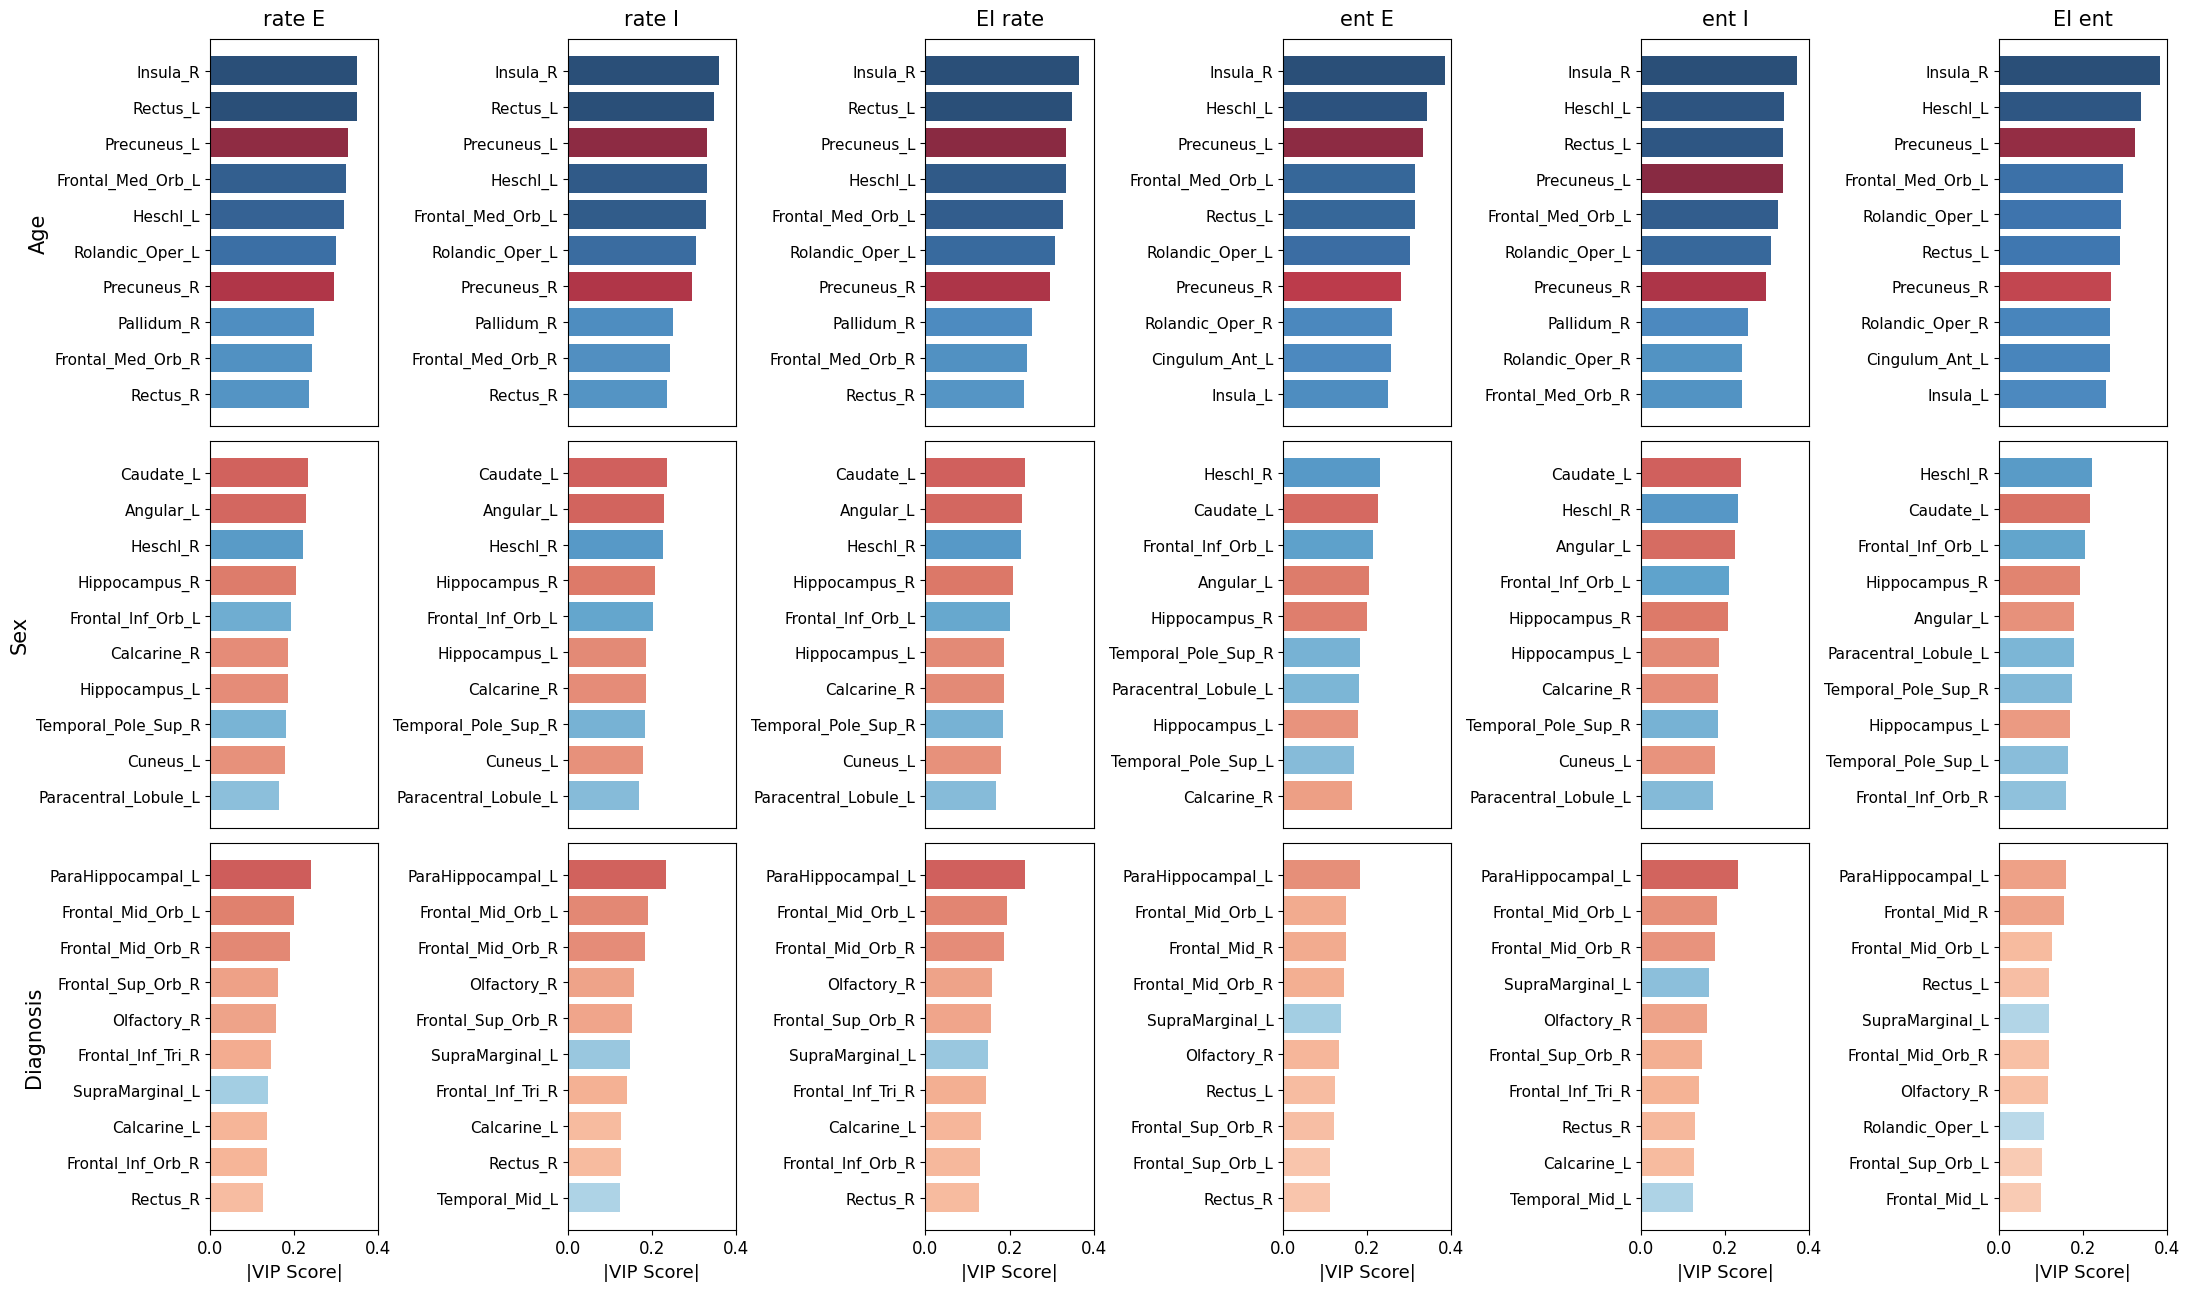

In [11]:
# --- VIP Barplots by Region (replicating pcev_feature_effects_analysis_age style, improved) ---
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
import matplotlib as mpl
import warnings

# Load brain region names (column 'label' in ROI_MNI_V4.csv)
roi_df = pd.read_csv(REPO_ROOT / 'data/derived/ROI_MNI_V4.csv')
roi_regions = roi_df['label'].tolist()

# Helper: feature to label (e.g. 'rate_E_5' -> 'rate_E [Frontal_Sup_L]')
def feature_to_label(feature: str) -> str:
    parts = feature.split('_')
    prefix = '_'.join(parts[:-1]) if len(parts) > 1 else feature
    try:
        suffix = int(parts[-1])
        region_name = roi_regions[suffix] if suffix < len(roi_regions) else f'ROI {suffix}'
    except (ValueError, IndexError):
        region_name = 'Unknown'
    return f'{prefix} [{region_name}]'

# Prepare color mapping: RdBu_r colormap for VIP values
cmap = mpl.cm.get_cmap('RdBu_r')
norm = mpl.colors.Normalize(vmin=-0.35, vmax=0.35)

# Plotting
fig, axes = plt.subplots(3, 6, figsize=(22, 14), sharey=False)
phenotypes = [('Age', age_vip_df), ('Sex', sex_vip_df), ('Diagnosis', diag_vip_df)]

for row, (pheno_name, df) in enumerate(phenotypes):
    for col, group in enumerate(vip_feature_groups):
        ax = axes[row, col]
        sub = df[df['feature_group'] == group].copy()
        sub['abs_vip'] = sub['vip'].abs()
        top = sub.sort_values('abs_vip', ascending=False).head(10)
        top['label'] = top['feature'].map(feature_to_label)
        # Do NOT reverse: largest at top (default for barh)
        bar_colors = [cmap(norm(v)) for v in top['vip']]
        ax.barh(top['label'], top['abs_vip'], color=bar_colors, alpha=0.85)
        # Remove prefix and square brackets from labels for y-ticks
        # Suppress UserWarning for set_yticklabels with contextlib
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            ax.set_yticklabels([lbl.split('[')[-1].replace(']', '').strip() for lbl in top['label']])
        ax.invert_yaxis()
        if row == 2:
            ax.set_xlabel('|VIP Score|', fontsize=13)
            ax.tick_params(axis='x', labelsize=12)
        else:
            ax.set_xlabel('')
            ax.tick_params(axis='x', bottom=False, top=False, labelbottom=False)
        if row == 0:
            ax.set_title(group.replace('_', ' '), fontsize=15, pad=10)
        if col == 0:
            ax.set_ylabel(pheno_name, fontsize=15)
        else:
            ax.set_ylabel('')
        # ax.grid(axis='x', color='0.9', linestyle='--', linewidth=1)
        ax.tick_params(axis='y', labelsize=11)
        
        # Set x axis to [0, 0.4] for all
        ax.set_xlim(0, 0.4)

# Legend (colorbar for VIP values)
# sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.03, pad=0.08, aspect=40)
# cbar.set_label('VIP Value', fontsize=14)

fig.tight_layout(rect=[0, 0.07, 1, 1])

fig.savefig(FIG_DIR / 'pehnotypes_VIP_barplots.png', dpi=200, bbox_inches='tight')
fig.savefig(FIG_DIR / 'pehnotypes_VIP_barplots.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'pehnotypes_VIP_barplots.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


In [12]:
import vtk

def _patch_vtk_mro_for_vtkname():
    probe = vtk.vtkPolyData()
    for cls in probe.__class__.mro():
        if cls is object:
            continue
        if not hasattr(cls, "__vtkname__"):
            nm = cls.__name__
            if not nm.startswith("vtk"):
                nm = f"vtk{nm}"
            cls.__vtkname__ = nm

_patch_vtk_mro_for_vtkname()

import numpy as np
import brainspace.plotting.base as bs_base

def patched_to_numpy(self, transparent_bg=True, scale=None):
    wf = self._win2img(transparent_bg, scale)
    img = bs_base.get_output(wf)

    dims = None
    if hasattr(img, "GetDimensions"):
        try:
            dims = img.GetDimensions()
        except Exception:
            dims = None
    if dims is None and hasattr(img, "dimensions"):
        d = img.dimensions
        if isinstance(d, tuple):
            dims = d
        elif callable(d):
            dims = d()
        else:
            dims = d
    dims = tuple(dims)
    shape = dims[::-1][1:] + (-1,)

    scalars = img.PointData['ImageScalars']
    if hasattr(scalars, "to_array"):
        scalars = scalars.to_array()
    scalars = np.asarray(scalars)
    return scalars.reshape(shape)[::-1]

bs_base.Plotter.to_numpy = patched_to_numpy




In [13]:
# --- Brain Plotting Function for VIP Scores ---
import sys
sys.path.append(str(Path('/home/rherzog/Documents/Brainlat/brainplot')))
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
import nibabel as nb

# Helper to remove indices 70-77 (inclusive) from a 90-region vector
def remove_excluded_regions(vec):
    # Remove indices 70 to 77 (inclusive)
    mask = np.ones(90, dtype=bool)
    mask[70:78] = False
    return np.array(vec)[mask]

# Helper to plot a brain map for a vector of 82 values
def plot_brain_map(mapp, name, vmin=-0.3, vmax=0.3, cmap='seismic', savefile=None):
    # Load GIFTI label files
    lh_labels_gii = nb.load('/home/rherzog/Documents/Brainlat/brainplot/AAL.32k.L.label.gii')
    lh_labels = lh_labels_gii.darrays[0].data.astype(int)
    rh_labels_gii = nb.load('/home/rherzog/Documents/Brainlat/brainplot/AAL.32k.R.label.gii')
    rh_labels = rh_labels_gii.darrays[0].data.astype(int)

    # Split into left/right hemispheres and insert dummy values as in heatmap_brain.py
    Ds_left = mapp[::2]
    Ds_right = mapp[1::2]

    # Map each vertex to its corresponding value
    lh_vertex_data = np.zeros_like(lh_labels, dtype=float)
    for i in range(41):
        lh_vertex_data[lh_labels == i+1] = Ds_left[i]
    rh_vertex_data = np.zeros_like(rh_labels, dtype=float)
    for i in range(41):
        rh_vertex_data[rh_labels == i+1] = Ds_right[i]

    surfaces = fetch_fslr()
    lh, rh = surfaces['inflated']
    # Use 2x2 grid layout for brain views, increase zoom and reduce size for less spacing
    # p = Plot(lh, rh, size=(1000, 800), layout='grid', zoom=1.15)
    p = Plot(lh, rh, size=(1000, 800), layout='grid', zoom=1.5)

    p.add_layer({'left': lh_vertex_data, 'right': rh_vertex_data},
                cmap=cmap, cbar=False, color_range=(vmin, vmax))
    fig = p.build()
    # Minimize space around brains
    # fig.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
    fig.patch.set_alpha(0)
    # fig.text(y=0.9, x=0.25, s=name, fontsize=24)
    if savefile:
        fig.savefig(savefile, dpi=200, transparent=True)
    return fig


## Brain VIP Maps (3×4 grid)

Each row = phenotype (Age, Sex, Diagnosis). Each column = feature group (`rate_E`, `EI_rate`, `ent_E`, `EI_ent`). Panels show brain maps of VIP correlations (score vs feature) after excluding regions 70–77.

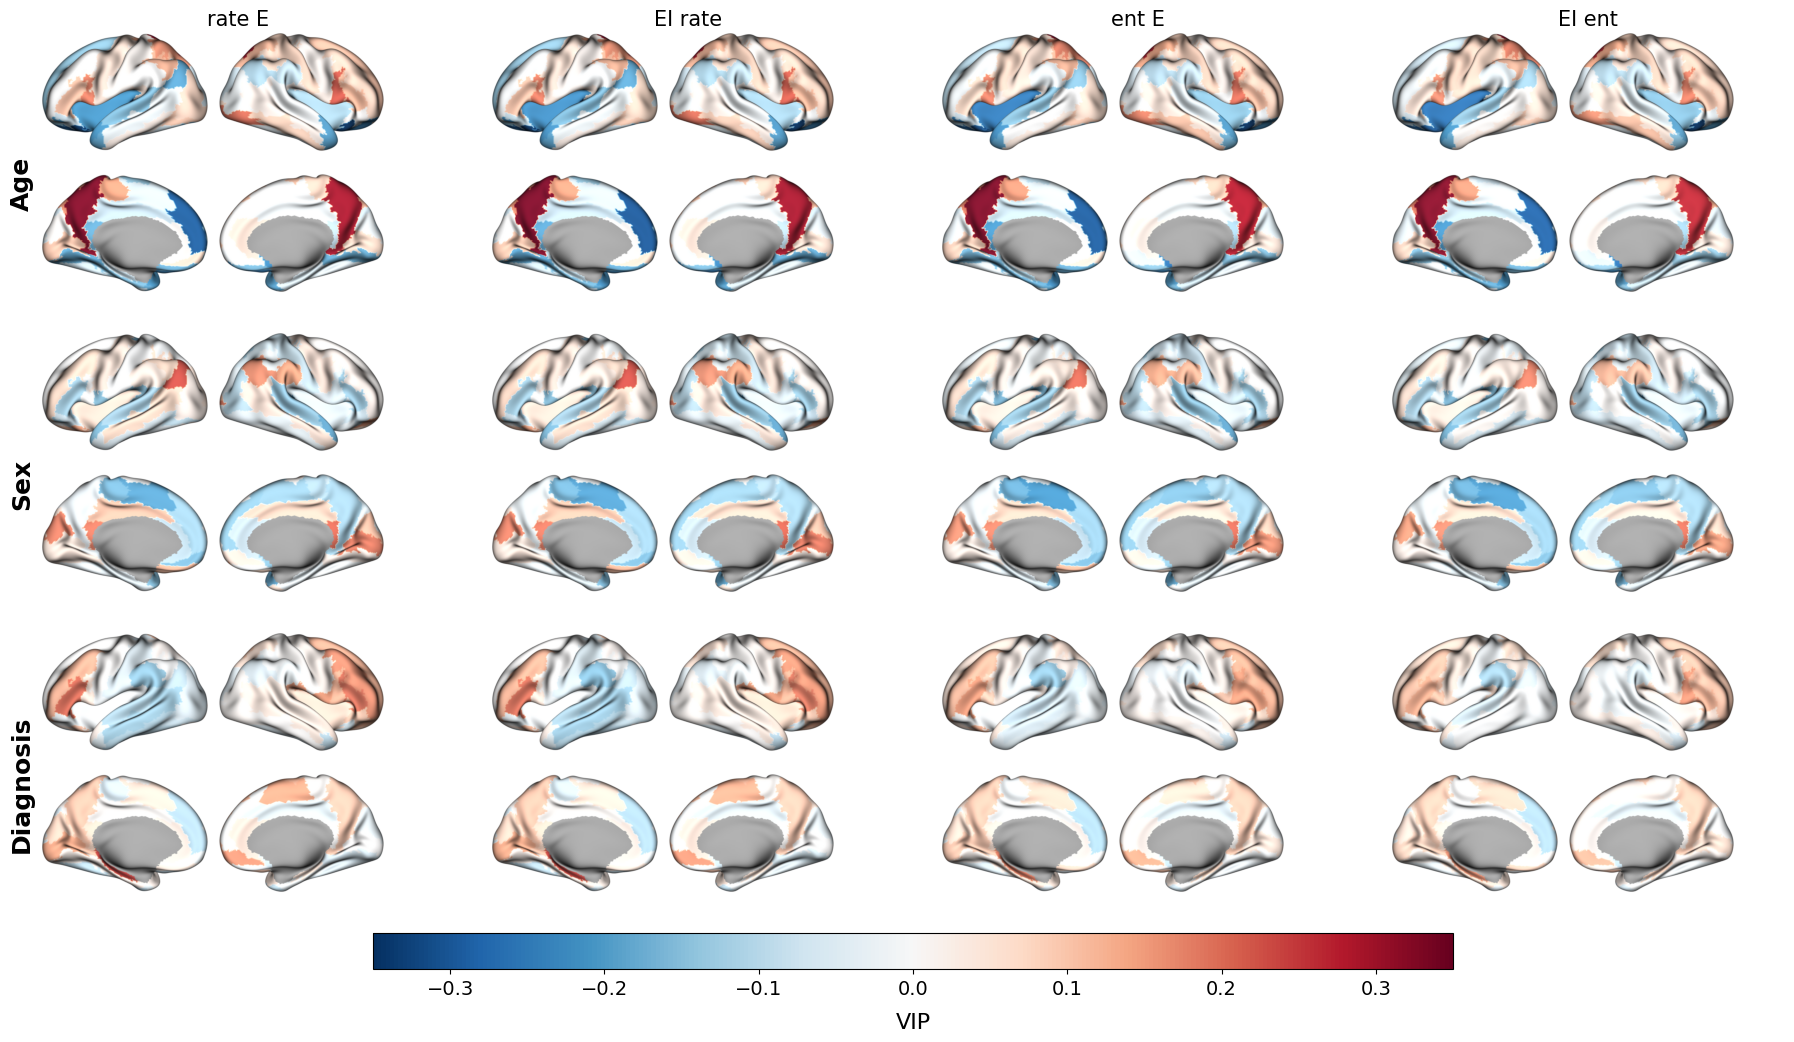

In [14]:
# 3×4 brain VIP grid (phenotype rows x feature-group columns)
# ONLY EXCITATORY AND EI FEATURES
vip_feature_groups_grid = ['rate_E', 'EI_rate', 'ent_E', 'EI_ent']

phenotypes = [
    ("Age", age_vip_df),
    ("Sex", sex_vip_df),
    ("Diagnosis", diag_vip_df),
]

nrows = len(phenotypes)
ncols = len(vip_feature_groups_grid)
BRAIN_VIP_FIGSIZE = (18, 9)  # Ajusta si quieres cerebros más grandes/pequeños

fig, axes = plt.subplots(nrows, ncols, figsize=BRAIN_VIP_FIGSIZE)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

def crop_image_auto(img, bg_threshold=10):
    # Recorta automáticamente los bordes "vacíos" (casi negros o casi blancos)
    # bg_threshold: tolerancia para considerar fondo (0=negro, 255=blanco)
    mask = (img > bg_threshold).any(axis=2) & (img < 255-bg_threshold).any(axis=2)
    if not mask.any():
        return img  # no hay nada que recortar
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    if len(rows) == 0 or len(cols) == 0:
        return img
    return img[rows[0]:rows[-1]+100, cols[0]:cols[-1]+500, :]

# Store vmin/vmax/cmap for colorbar
vip_vmin = -0.35
vip_vmax = 0.35
vip_cmap = 'RdBu_r'

for row, (pheno_name, vip_df) in enumerate(phenotypes):
    for col, group in enumerate(vip_feature_groups_grid):
        ax = axes[row, col]
        vip_vec = (
            vip_df[vip_df['feature_group'] == group]
            .sort_values('feature', key=lambda x: x.str.extract(r'_(\d+)$').astype(int)[0])
            .vip.values
        )
        vip_vec_82 = remove_excluded_regions(vip_vec)
        brain_fig = plot_brain_map(vip_vec_82, name=f"{pheno_name}{group}", 
                                   vmin=vip_vmin, vmax=vip_vmax, cmap=vip_cmap, savefile=None)
        brain_fig.canvas.draw()
        buf = brain_fig.canvas.buffer_rgba()
        img = np.asarray(buf).reshape(brain_fig.canvas.get_width_height()[::-1] + (4,))
        img = img[..., :3]  # drop alpha
        img_cropped = crop_image_auto(img)
        ax.imshow(img_cropped)
        plt.close(brain_fig)
        ax.axis('off')
        if row == 0:
            ax.set_title(group.replace('_', ' '), fontsize=15)
    # Etiqueta de fenotipo a la izquierda
    axes[row, 0].text(-0.05, 0.5, pheno_name, 
                      va='center', ha='center', fontsize=18, rotation=90, 
                      transform=axes[row, 0].transAxes, fontweight='bold')

# Add horizontal colorbar at the bottom
from matplotlib.colors import Normalize
import matplotlib.cm as cm
cbar_ax = fig.add_axes([0.2, -0.04, 0.6, 0.04])  # [left, bottom, width, height] in figure fraction
norm = Normalize(vmin=vip_vmin, vmax=vip_vmax)
sm = cm.ScalarMappable(cmap=vip_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('VIP', fontsize=16, labelpad=10)
cbar.ax.tick_params(labelsize=14)


# # Save figure as PNG and PDF (PDF should be editable in Illustrator/Inkscape)
fig.savefig(FIG_DIR / 'phenotypes_brain_vip_grid_E.png', dpi=200, bbox_inches='tight')
fig.savefig(FIG_DIR / 'phenotypes_brain_vip_grid_E.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'phenotypes_brain_vip_grid_E.svg', dpi=300, bbox_inches='tight', transparent=True)

# plt.show()

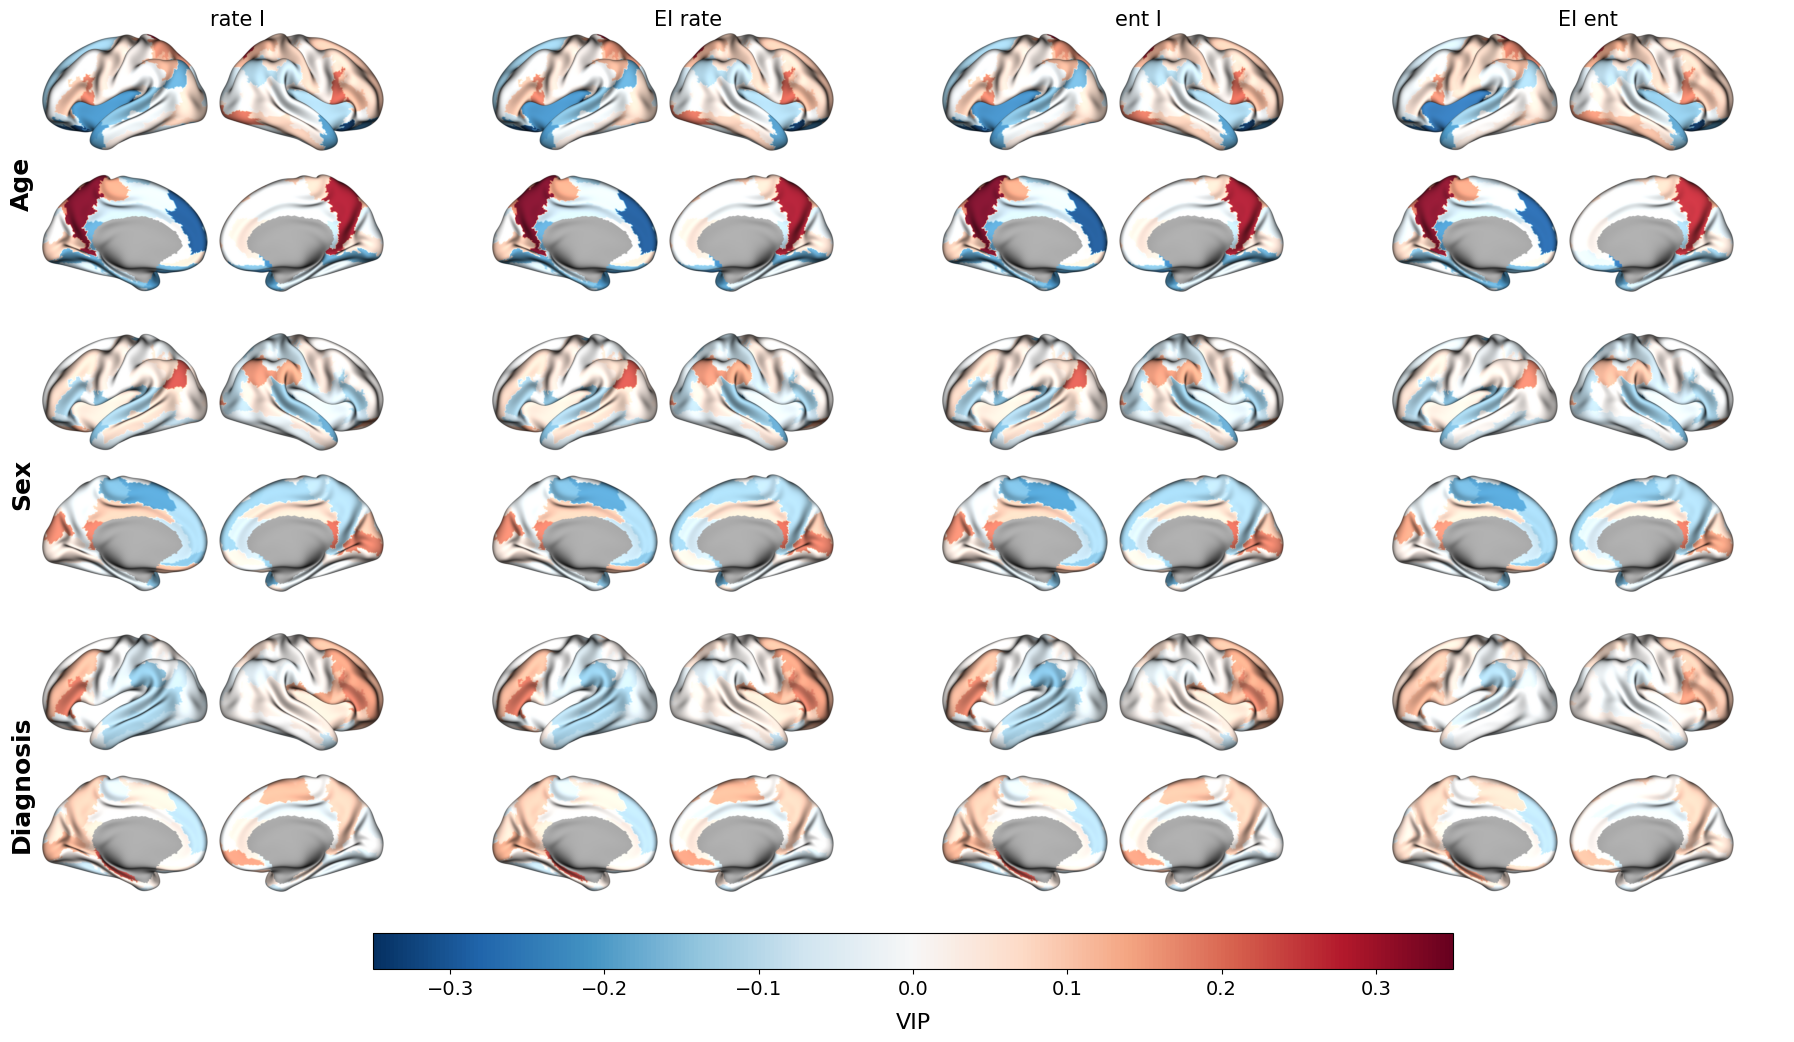

In [15]:
# 3×4 brain VIP grid (phenotype rows x feature-group columns)
# ONLY INHIBITORY AND EI FEATURES

vip_feature_groups_grid = ['rate_I', 'EI_rate', 'ent_I', 'EI_ent']
phenotypes = [
    ("Age", age_vip_df),
    ("Sex", sex_vip_df),
    ("Diagnosis", diag_vip_df),
]

nrows = len(phenotypes)
ncols = len(vip_feature_groups_grid)
BRAIN_VIP_FIGSIZE = (18, 9)  # Ajusta si quieres cerebros más grandes/pequeños

fig, axes = plt.subplots(nrows, ncols, figsize=BRAIN_VIP_FIGSIZE)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

def crop_image_auto(img, bg_threshold=10):
    # Recorta automáticamente los bordes "vacíos" (casi negros o casi blancos)
    # bg_threshold: tolerancia para considerar fondo (0=negro, 255=blanco)
    mask = (img > bg_threshold).any(axis=2) & (img < 255-bg_threshold).any(axis=2)
    if not mask.any():
        return img  # no hay nada que recortar
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    if len(rows) == 0 or len(cols) == 0:
        return img
    return img[rows[0]:rows[-1]+100, cols[0]:cols[-1]+500, :]

# Store vmin/vmax/cmap for colorbar
vip_vmin = -0.35
vip_vmax = 0.35
vip_cmap = 'RdBu_r'

for row, (pheno_name, vip_df) in enumerate(phenotypes):
    for col, group in enumerate(vip_feature_groups_grid):
        ax = axes[row, col]
        vip_vec = (
            vip_df[vip_df['feature_group'] == group]
            .sort_values('feature', key=lambda x: x.str.extract(r'_(\d+)$').astype(int)[0])
            .vip.values
        )
        vip_vec_82 = remove_excluded_regions(vip_vec)
        brain_fig = plot_brain_map(vip_vec_82, name=f"{pheno_name}{group}", 
                                   vmin=vip_vmin, vmax=vip_vmax, cmap=vip_cmap, savefile=None)
        brain_fig.canvas.draw()
        buf = brain_fig.canvas.buffer_rgba()
        img = np.asarray(buf).reshape(brain_fig.canvas.get_width_height()[::-1] + (4,))
        img = img[..., :3]  # drop alpha
        img_cropped = crop_image_auto(img)
        ax.imshow(img_cropped)
        plt.close(brain_fig)
        ax.axis('off')
        if row == 0:
            ax.set_title(group.replace('_', ' '), fontsize=15)
    # Etiqueta de fenotipo a la izquierda
    axes[row, 0].text(-0.05, 0.5, pheno_name, 
                      va='center', ha='center', fontsize=18, rotation=90, 
                      transform=axes[row, 0].transAxes, fontweight='bold')

# Add horizontal colorbar at the bottom
from matplotlib.colors import Normalize
import matplotlib.cm as cm
cbar_ax = fig.add_axes([0.2, -0.04, 0.6, 0.04])  # [left, bottom, width, height] in figure fraction
norm = Normalize(vmin=vip_vmin, vmax=vip_vmax)
sm = cm.ScalarMappable(cmap=vip_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('VIP', fontsize=16, labelpad=10)
cbar.ax.tick_params(labelsize=14)


# Save figure as PNG and PDF (PDF should be editable in Illustrator/Inkscape)
fig.savefig(FIG_DIR / 'phenotypes_brain_vip_grid_I.png', dpi=200, bbox_inches='tight')
fig.savefig(FIG_DIR / 'phenotypes_brain_vip_grid_I.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'phenotypes_brain_vip_grid_I.svg', dpi=300, bbox_inches='tight', transparent=True)

plt.show()


## EI Rate VIP summary
Top single-region VIPs for the EI_rate feature group using the best PCEV scores per phenotype (diagnosis uses the all-features model). The list below reports the five strongest regions (by |VIP|) and the sign of their correlation with the PCEV score.



In [16]:

# Summarize top 5 EI_rate VIP per phenotype (direction via sign)
from IPython.display import display

summary_feature = 'EI_rate'
phenotype_vip_sources = [
    ('Age', age_vip_df),
    ('Sex', sex_vip_df),
    ('Diagnosis', diag_vip_df),
]

def summarize_top_vip(vip_df, feature_group, top_k=10):
    sub = vip_df[vip_df['feature_group'] == feature_group].copy()
    if sub.empty:
        raise ValueError(f"No VIP rows for feature group {feature_group}")
    sub['abs_vip'] = sub['vip'].abs()
    top = sub.sort_values('abs_vip', ascending=False).head(top_k).copy()
    top['label'] = top['feature'].apply(feature_to_label)
    return top[['label', 'vip', 'abs_vip']]

paragraphs = []
for name, df in phenotype_vip_sources:
    top = summarize_top_vip(df, summary_feature)
    # Display table for quick inspection
    display(top[['label', 'vip']].rename(columns={'label': 'Region', 'vip': 'VIP'}))
    bullet = '; '.join([f"{row.label} ({row.vip:+.3f})" for row in top.itertuples()])
    paragraphs.append(f"{name}: top {summary_feature} VIP regions (sign shows direction): {bullet}.")

print("".join(paragraphs))


,Region,VIP
209,EI_rate [Insula_R],-0.365045
206,EI_rate [Rectus_L],-0.347863
246,EI_rate [Precuneus_L],0.333889
258,EI_rate [Heschl_L],-0.333340
204,EI_rate [Frontal_Med_Orb_L],-0.327806
196,EI_rate [Rolandic_Oper_L],-0.307167
247,EI_rate [Precuneus_R],0.295485
255,EI_rate [Pallidum_R],-0.254057
205,EI_rate [Frontal_Med_Orb_R],-0.242502
207,EI_rate [Rectus_R],-0.235132


,Region,VIP
250,EI_rate [Caudate_L],0.237693
244,EI_rate [Angular_L],0.229571
259,EI_rate [Heschl_R],-0.227325
217,EI_rate [Hippocampus_R],0.208281
194,EI_rate [Frontal_Inf_Orb_L],-0.200323
216,EI_rate [Hippocampus_L],0.187373
223,EI_rate [Calcarine_R],0.186834
263,EI_rate [Temporal_Pole_Sup_R],-0.183622
224,EI_rate [Cuneus_L],0.178863
248,EI_rate [Paracentral_Lobule_L],-0.168161


,Region,VIP
218,EI_rate [ParaHippocampal_L],0.236122
188,EI_rate [Frontal_Mid_Orb_L],0.192674
189,EI_rate [Frontal_Mid_Orb_R],0.185658
201,EI_rate [Olfactory_R],0.158199
185,EI_rate [Frontal_Sup_Orb_R],0.155519
242,EI_rate [SupraMarginal_L],-0.149114
193,EI_rate [Frontal_Inf_Tri_R],0.144366
222,EI_rate [Calcarine_L],0.132550
195,EI_rate [Frontal_Inf_Orb_R],0.129420
207,EI_rate [Rectus_R],0.127566


Age: top EI_rate VIP regions (sign shows direction): EI_rate [Insula_R] (-0.365); EI_rate [Rectus_L] (-0.348); EI_rate [Precuneus_L] (+0.334); EI_rate [Heschl_L] (-0.333); EI_rate [Frontal_Med_Orb_L] (-0.328); EI_rate [Rolandic_Oper_L] (-0.307); EI_rate [Precuneus_R] (+0.295); EI_rate [Pallidum_R] (-0.254); EI_rate [Frontal_Med_Orb_R] (-0.243); EI_rate [Rectus_R] (-0.235).Sex: top EI_rate VIP regions (sign shows direction): EI_rate [Caudate_L] (+0.238); EI_rate [Angular_L] (+0.230); EI_rate [Heschl_R] (-0.227); EI_rate [Hippocampus_R] (+0.208); EI_rate [Frontal_Inf_Orb_L] (-0.200); EI_rate [Hippocampus_L] (+0.187); EI_rate [Calcarine_R] (+0.187); EI_rate [Temporal_Pole_Sup_R] (-0.184); EI_rate [Cuneus_L] (+0.179); EI_rate [Paracentral_Lobule_L] (-0.168).Diagnosis: top EI_rate VIP regions (sign shows direction): EI_rate [ParaHippocampal_L] (+0.236); EI_rate [Frontal_Mid_Orb_L] (+0.193); EI_rate [Frontal_Mid_Orb_R] (+0.186); EI_rate [Olfactory_R] (+0.158); EI_rate [Frontal_Sup_Orb_R] (+0